# Week 6 Tutorial - Ensemble Methods

**How to use this notebook:**
Read one section of `study-guide.md`, then do that section here before moving on.

Each section has:
- A worked example (pre-written - just run it)
- A **DO IT YOURSELF** cell with different data

---

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed. Run: pip install xgboost')

# Breast cancer dataset for examples
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Wine dataset for do-it-yourself
wine = load_wine()
X_w, y_w = wine.data, wine.target
X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(X_w, y_w, test_size=0.2, random_state=42, stratify=y_w)

print('Cancer dataset:', X_train.shape, '| Wine dataset:', X_w_train.shape)

Cancer dataset: (455, 30) | Wine dataset: (142, 13)


---
## Section 1 - Decision Trees
### EXAMPLE

In [58]:
# EXAMPLE: effect of max_depth on decision tree performance

depths = [1, 2, 3, 5, 10, None]

print(f'max_depth  train_acc  cv_acc')
print('-' * 35)

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    train_acc = dt.fit(X_train, y_train).score(X_train, y_train)
    cv_acc = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy').mean()
    label = str(depth) if depth else 'None'
    print(f'{label:>9}  {train_acc:>9.4f}  {cv_acc:>6.4f}')

print()
print('Notice: train_acc hits 1.0 at high depth (memorizing) but cv_acc drops')

max_depth  train_acc  cv_acc
-----------------------------------
        1     0.9231  0.8967
        2     0.9582  0.9187
        3     0.9758  0.9253
        5     0.9934  0.9319
       10     1.0000  0.9099
     None     1.0000  0.9099

Notice: train_acc hits 1.0 at high depth (memorizing) but cv_acc drops


### DO IT YOURSELF - Section 1
Dataset: wine (3 classes, 13 features)

1. Try `max_depth = 1, 2, 3, 5, 10, None` on the wine dataset
2. Print train accuracy and CV accuracy for each
3. At what depth does overfitting start? (train_acc much higher than cv_acc)
4. Train the best depth and print classification report

In [59]:
# DO IT YOURSELF - Section 1
# YOUR CODE HERE
depths = [1, 2, 3, 5, 10, None]

print(f'max_depth  train_acc  cv_acc')
print('-' * 35)
for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    train_acc = dt.fit(X_w_train, y_w_train).score(X_w_train, y_w_train)
    cv_acc = cross_val_score(dt, X_w_train, y_w_train, cv=5, scoring='accuracy').mean()
    label = str(depth) if depth else 'None'
    print(f'{label:>9}  {train_acc:>9.4f}  {cv_acc:>6.4f}')

print()

# Best depth 3

dt_best = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_best.fit(X_w_train, y_w_train)
y_w_pred = dt_best.predict(X_w_test)
print(classification_report(y_w_test, y_w_pred, target_names=wine.target_names))

max_depth  train_acc  cv_acc
-----------------------------------
        1     0.6620  0.6411
        2     0.9366  0.8951
        3     0.9930  0.9232
        5     1.0000  0.9163
       10     1.0000  0.9163
     None     1.0000  0.9163

              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



---
## Section 2 - Random Forest
### EXAMPLE

In [60]:
# EXAMPLE: Random Forest vs single Decision Tree on breast cancer

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

dt_cv = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')

print(f'Decision Tree CV:  {dt_cv.mean():.4f} +- {dt_cv.std():.4f}')
print(f'Random Forest CV:  {rf_cv.mean():.4f} +- {rf_cv.std():.4f}')
print()
print('RF should be higher mean AND lower std (more consistent)')

Decision Tree CV:  0.9099 +- 0.0189
Random Forest CV:  0.9538 +- 0.0235

RF should be higher mean AND lower std (more consistent)


Top 10 most important features:
Feature                             Importance
-----------------------------------------------
worst area                              0.1400
worst concave points                    0.1295
worst radius                            0.0977
mean concave points                     0.0909
worst perimeter                         0.0722
mean perimeter                          0.0696
mean radius                             0.0687
mean concavity                          0.0576
mean area                               0.0492
worst concavity                         0.0343


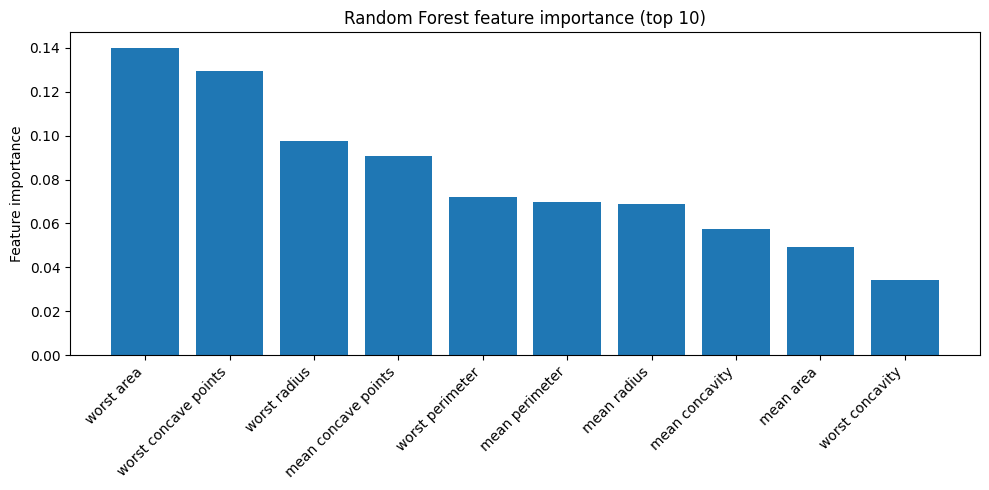

In [61]:
# EXAMPLE: feature importance from Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_names = cancer.feature_names
sorted_idx = np.argsort(importances)[::-1]

print('Top 10 most important features:')
print(f'{"Feature":<35} {"Importance":>10}')
print('-' * 47)
for i in sorted_idx[:10]:
    print(f'{feature_names[i]:<35} {importances[i]:>10.4f}')

# bar chart
plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[sorted_idx[:10]])
plt.xticks(range(10), [feature_names[i] for i in sorted_idx[:10]], rotation=45, ha='right')
plt.ylabel('Feature importance')
plt.title('Random Forest feature importance (top 10)')
plt.tight_layout()
plt.show()

### DO IT YOURSELF - Section 2
Dataset: wine

1. Train a Random Forest on wine with `n_estimators=100`
2. Compare CV accuracy to the single Decision Tree from Section 1
3. Plot the top 10 feature importances as a bar chart
4. Which features matter most for classifying wine type?

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Top 10 most important features:
Feature                             Importance
-----------------------------------------------
color_intensity                         0.1876
flavanoids                              0.1596
proline                                 0.1468
alcohol                                 0.1179
hue                                     0.1015
od280/od315_of_diluted_wines            0.0963
total_phenols                           0.0415
magnesium                               0.0401
malic_acid                              0.0339
alcalinity_of_ash                       0.0255


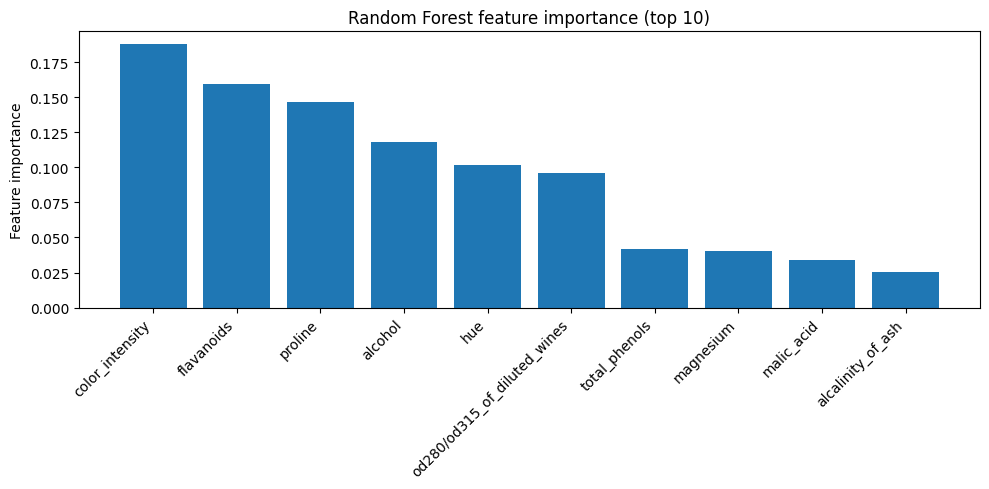

In [62]:
# DO IT YOURSELF - Section 2
# YOUR CODE HERE
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_w_train, y_w_train)
y_w_pred = rf.predict(X_w_test)
print(classification_report(y_w_test, y_w_pred, target_names=wine.target_names))
# random forest has almost perfect score much better than single decision tree

importances = rf.feature_importances_
feature_names = wine.feature_names
sorted_idx = np.argsort(importances)[::-1]

print('Top 10 most important features:')
print(f'{"Feature":<35} {"Importance":>10}')
print('-' * 47)
for i in sorted_idx[:10]:
    print(f'{feature_names[i]:<35} {importances[i]:>10.4f}')

# bar chart
plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[sorted_idx[:10]])
plt.xticks(range(10), [feature_names[i] for i in sorted_idx[:10]], rotation=45, ha='right')
plt.ylabel('Feature importance')
plt.title('Random Forest feature importance (top 10)')
plt.tight_layout()
plt.show()

# color_intensity has the highest feature importance contributing to 18.7% of total importance
#

---
## Section 3 - Gradient Boosting
### EXAMPLE

In [63]:
# EXAMPLE: Gradient Boosting vs Random Forest on breast cancer

rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
gb_cv = cross_val_score(gb, X_train, y_train, cv=5, scoring='accuracy')

print(f'Random Forest CV:       {rf_cv.mean():.4f} +- {rf_cv.std():.4f}')
print(f'Gradient Boosting CV:   {gb_cv.mean():.4f} +- {gb_cv.std():.4f}')

Random Forest CV:       0.9538 +- 0.0235
Gradient Boosting CV:   0.9582 +- 0.0108


In [64]:
# EXAMPLE: effect of learning_rate on gradient boosting

learning_rates = [0.001, 0.01, 0.1, 0.3, 1.0]

print(f'{"learning_rate":>15}  {"CV accuracy":>12}')
print('-' * 30)

for lr in learning_rates:
    gb = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, max_depth=3, random_state=42)
    cv = cross_val_score(gb, X_train, y_train, cv=5, scoring='accuracy').mean()
    print(f'{lr:>15}  {cv:>12.4f}')

print()
print('Very low lr: not enough steps to converge')
print('Very high lr: overshoots, unstable')

  learning_rate   CV accuracy
------------------------------
          0.001        0.6264
           0.01        0.9451
            0.1        0.9582
            0.3        0.9582
            1.0        0.9582

Very low lr: not enough steps to converge
Very high lr: overshoots, unstable


### DO IT YOURSELF - Section 3
Dataset: wine

1. Train GradientBoostingClassifier on wine with `n_estimators=100, max_depth=3`
2. Try `learning_rate = 0.01, 0.05, 0.1, 0.3` - print CV accuracy for each
3. Train the best learning_rate and print classification report
4. Comment: how does gradient boosting compare to Random Forest from Section 2?

In [65]:
# DO IT YOURSELF - Section 3
# YOUR CODE HERE
learning_rates = [0.001, 0.01, 0.1, 0.3, 1.0]

print(f'{"learning_rate":>15}  {"CV accuracy":>12}')
print('-' * 30)

for lr in learning_rates:
    gb = XGBClassifier(n_estimators=100, learning_rate=lr, max_depth=3, random_state=42)
    cv = cross_val_score(gb, X_w_train, y_w_train, cv=5, scoring='accuracy').mean()
    print(f'{lr:>15}  {cv:>12.4f}')

gb_best = XGBClassifier(n_estimators=100, learning_rate=1.0, max_depth=3, random_state=42)
gb_best.fit(X_w_train, y_w_train)
y_w_pred = gb_best.predict(X_w_test)
print(classification_report(y_w_test, y_w_pred, target_names=wine.target_names))

# it is not as accurate as the RF, however it could be that there isn't a lot of data so results from both could be overfit
# so it is hard to say which performs better.  But it is also note that random tree is probably optimized with little tuning.
# so could be that we see lower accuracy because further tuning is needed on this model.
# conclusion, not too sure

  learning_rate   CV accuracy
------------------------------
          0.001        0.9300
           0.01        0.9443
            0.1        0.9512
            0.3        0.9443
            1.0        0.9512
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



---
## Section 4 - Bias-Variance Tradeoff
### EXAMPLE

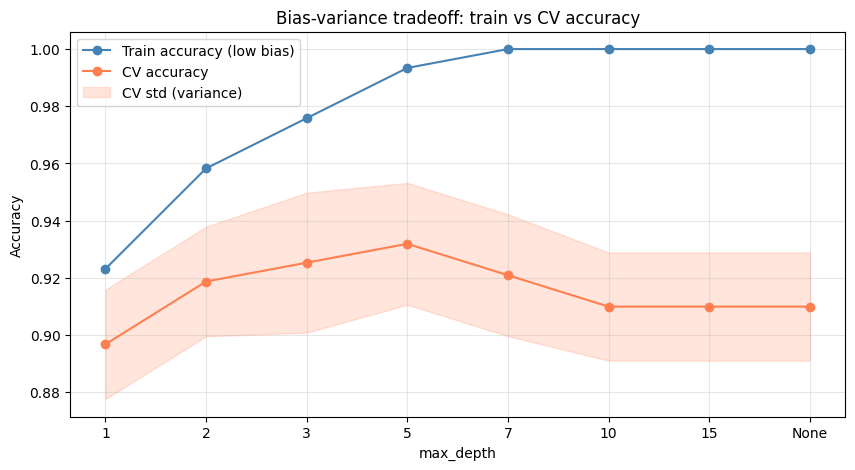

Gap between train and CV = overfitting (high variance)
Both low = underfitting (high bias)


In [66]:
# EXAMPLE: visualize bias-variance tradeoff using max_depth
# High depth = low bias (fits training well) but high variance (unstable across folds)

depths = [1, 2, 3, 5, 7, 10, 15, None]
train_accs = []
cv_means = []
cv_stds = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(dt.score(X_train, y_train))
    scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

x = range(len(depths))
labels = [str(d) if d else 'None' for d in depths]

plt.figure(figsize=(10, 5))
plt.plot(x, train_accs, 'steelblue', marker='o', label='Train accuracy (low bias)')
plt.plot(x, cv_means, 'coral', marker='o', label='CV accuracy')
plt.fill_between(x,
                 [m - s for m, s in zip(cv_means, cv_stds)],
                 [m + s for m, s in zip(cv_means, cv_stds)],
                 alpha=0.2, color='coral', label='CV std (variance)')
plt.xticks(x, labels)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Bias-variance tradeoff: train vs CV accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('Gap between train and CV = overfitting (high variance)')
print('Both low = underfitting (high bias)')

### DO IT YOURSELF - Section 4
Dataset: wine

1. Reproduce the bias-variance plot above using the wine dataset
2. At what depth does the gap between train and CV accuracy become large?
3. Comment: what does that gap tell you about the model?

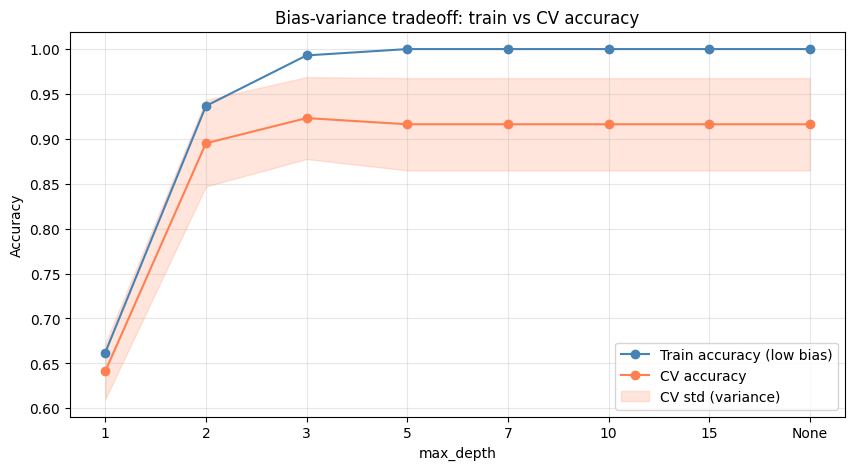

In [67]:
# DO IT YOURSELF - Section 4
# YOUR CODE HERE
depths = [1, 2, 3, 5, 7, 10, 15, None]
train_accs = []
cv_means = []
cv_stds = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_w_train, y_w_train)
    train_accs.append(dt.score(X_w_train, y_w_train))
    scores = cross_val_score(dt, X_w_train, y_w_train, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

plt.figure(figsize=(10, 5))
plt.plot(x, train_accs, 'steelblue', marker='o', label='Train accuracy (low bias)')
plt.plot(x, cv_means, 'coral', marker='o', label='CV accuracy')
plt.fill_between(x,
                 [m - s for m, s in zip(cv_means, cv_stds)],
                 [m + s for m, s in zip(cv_means, cv_stds)],
                 alpha=0.2, color='coral', label='CV std (variance)')
plt.xticks(x, labels)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Bias-variance tradeoff: train vs CV accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#2 . depth at greater or equal to 5 it gets big
#  consistent gap after depth 3 tells us that this data is relatively low bias and low variance

---
## Section 5 - Hyperparameter Tuning
### EXAMPLE

In [68]:
# EXAMPLE: GridSearchCV on Random Forest (breast cancer)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print(f'Best CV accuracy: {grid.best_score_:.4f}')
print()
y_pred = grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV accuracy: 0.9604

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [69]:
# EXAMPLE: RandomizedSearchCV on GradientBoosting (faster than grid search)

param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)

print('Best params:', search.best_params_)
print(f'Best CV accuracy: {search.best_score_:.4f}')

Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
Best CV accuracy: 0.9758


### DO IT YOURSELF - Section 5
Dataset: wine

1. Use `GridSearchCV` to tune a Random Forest on wine
   - Try `n_estimators`: [50, 100, 200]
   - Try `max_depth`: [3, 5, None]
2. Print the best params and best CV accuracy
3. Evaluate the best model on the test set with classification report
4. Comment: did tuning improve over the default Random Forest from Section 2?

In [70]:
# DO IT YOURSELF - Section 5
# YOUR CODE HERE
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_w_train, y_w_train)
print('Best params:', grid.best_params_)
print(f'Best CV accuracy: {grid.best_score_:.4f}')
print()
y_w_pred = grid.best_estimator_.predict(X_w_test)
print(classification_report(y_w_test, y_w_pred, target_names=wine.target_names))

# it looks like it does. The classification report is perfect given training data had no exposure to test data
# its safe to be confident on the result.
# result compare to section 2 is actually same, but for gridsearch same accuracy was done with less n_estimators
# so it is safe to say model was finetuned to be optimized

Best params: {'max_depth': 3, 'n_estimators': 50}
Best CV accuracy: 0.9862

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



---
## CAPSTONE

1. Run all 3 ensemble models (DecisionTree, RandomForest, GradientBoosting) on the wine dataset
2. Use 5-fold CV, print mean +- std for each
3. Pick the best model, tune it with GridSearchCV or RandomizedSearchCV
4. Evaluate the tuned model on the test set — print classification report and confusion matrix
5. Plot feature importances for the best model
6. Written answer: which model won and why do you think that is?

Model                   CV Acc       Std
----------------------------------------
Decision Tree           0.9232    0.0456
Random Forest           0.9862    0.0276
Gradient Boost          0.9512    0.0416

Grid Search
Best params: {'max_depth': None, 'n_estimators': 100}
Best CV accuracy: 0.9931

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Random Search


c:\Users\yoonh\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params: {'n_estimators': 100, 'max_depth': None}
Best CV accuracy: 0.9931

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Top 10 most important features:
Feature                             Importance
-----------------------------------------------
color_intensity                         0.1854
flavanoids                              0.1610
proline                                 0.1528
alcohol                                 0.1212
hue                                     0.0998
od280/od315_of_diluted_wines            0.0948
total_phenols                           0.0415
magnesium                               0.0364
malic_acid                         

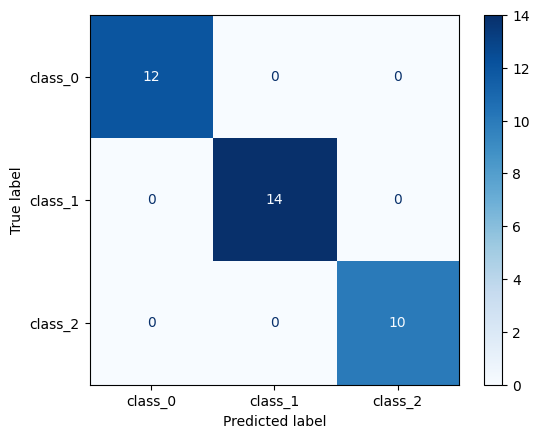

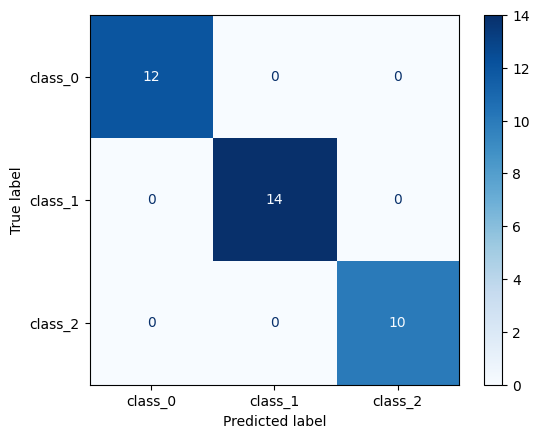

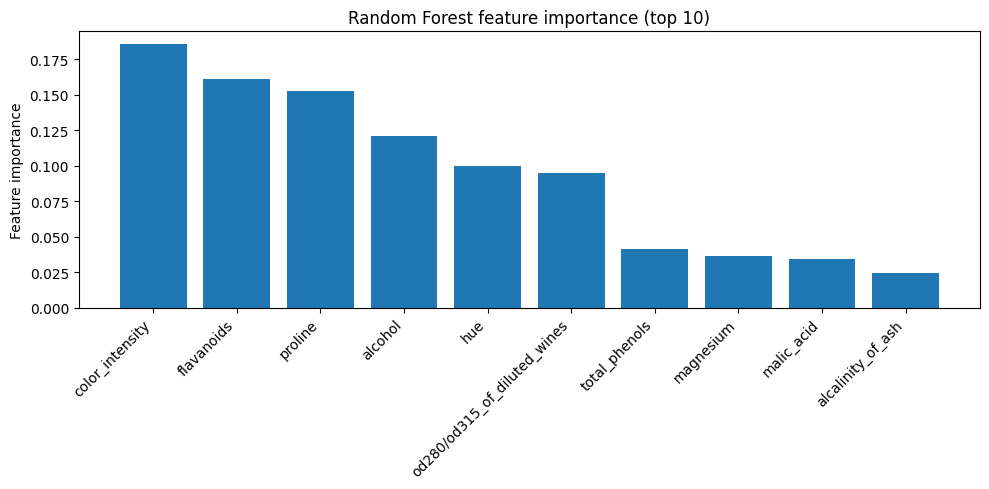

In [ ]:
# CAPSTONE
# YOUR CODE HERE
models = {
    'Decision Tree':   DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest':   RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boost':  XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
}

print(f'{"Model":<20}  {"CV Acc":>8}  {"Std":>8}')
print('-' * 40)

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_w_train, y_w_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:<20}  {scores.mean():>8.4f}  {scores.std():>8.4f}')

# Best one looks to be Random Forest

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, None]
}

param_dist = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [3, 5, 10, None],
}


hyper_param_models = {
    'Grid Search': GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy'),
    'Random Search': RandomizedSearchCV(RandomForestClassifier(), param_dist, n_iter=20, cv=5)
}

print()

for name, model in hyper_param_models.items():
    print(name)
    model.fit(X_w_train, y_w_train)
    print('Best params:', model.best_params_)
    print(f'Best CV accuracy: {model.best_score_:.4f}')
    print()
    y_w_pred = model.best_estimator_.predict(X_w_test)
    print(classification_report(y_w_test, y_w_pred, target_names=wine.target_names))
    cm = confusion_matrix(y_w_test, y_w_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
    disp.plot(cmap=plt.cm.Blues)
    print()

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_w_train, y_w_train)

importances = rf.feature_importances_
feature_names = wine.feature_names
sorted_idx = np.argsort(importances)[::-1]

print('Top 10 most important features:')
print(f'{"Feature":<35} {"Importance":>10}')
print('-' * 47)
for i in sorted_idx[:10]:
    print(f'{feature_names[i]:<35} {importances[i]:>10.4f}')

# bar chart
plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[sorted_idx[:10]])
plt.xticks(range(10), [feature_names[i] for i in sorted_idx[:10]], rotation=45, ha='right')
plt.ylabel('Feature importance')
plt.title('Random Forest feature importance (top 10)')
plt.tight_layout()
plt.show()

## Best model is using grid search with randomforest. gave most optimized and efficient parameter setting. in terms of accuracy it was same. So in that case choose the most efficient one.
